In [49]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

copper_pct = np.random.uniform(20, 80, n)
layers = np.random.randint(2, 16, n)
thickness = np.random.uniform(0.5, 3.0, n)
resin_pct = np.random.uniform(10, 40, n)
temperature = np.random.uniform(20, 180, n)

In [50]:
expansion = (
    0.01 * copper_pct
    + 0.08 * layers
    + 0.4 * thickness
    - 0.02 * resin_pct
    + 0.005 * temperature
    + np.random.normal(0, 0.2, n)
)

In [51]:
df = pd.DataFrame({
    "copper_pct": copper_pct,
    "layers": layers,
    "thickness": thickness,
    "resin_pct": resin_pct,
    "temperature": temperature,
    "expansion": expansion
})

In [52]:
df.head()

,copper_pct,layers,thickness,resin_pct,temperature,expansion
0,42.472407,8,2.180339,38.084643,24.241810,1.292673
1,77.042858,2,2.404049,30.880894,113.724093,1.785319
2,63.919637,5,1.094094,27.101835,170.436839,1.851525
3,55.919509,14,2.320541,12.915295,112.075868,2.744039
4,29.361118,5,1.419458,28.450217,82.107188,1.206795


In [53]:
df.describe()

,copper_pct,layers,thickness,resin_pct,temperature,expansion
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,48.210845,8.610000,1.780869,24.739657,103.110913,1.912543
std,17.849365,4.308542,0.731966,8.430283,49.838707,0.618393
min,20.331327,2.000000,0.512654,10.431805,21.734024,0.505283
25%,31.592046,5.000000,1.108638,17.970547,65.118340,1.497823
50%,47.848547,8.000000,1.890003,25.608594,107.611654,1.909939
75%,63.812187,13.000000,2.331963,31.083326,147.128722,2.397680
max,79.213216,15.000000,2.932526,39.701616,178.480823,3.385457


In [54]:
df.corr(numeric_only=True)

,copper_pct,layers,thickness,resin_pct,temperature,expansion
copper_pct,1.000000,0.008913,-0.114083,-0.104960,0.124408,0.270000
layers,0.008913,1.000000,0.156568,-0.022351,-0.045567,0.607140
thickness,-0.114083,0.156568,1.000000,-0.215176,-0.000845,0.563545
resin_pct,-0.104960,-0.022351,-0.215176,1.000000,0.004819,-0.362997
temperature,0.124408,-0.045567,-0.000845,0.004819,1.000000,0.398002
expansion,0.270000,0.607140,0.563545,-0.362997,0.398002,1.000000


<Axes: >

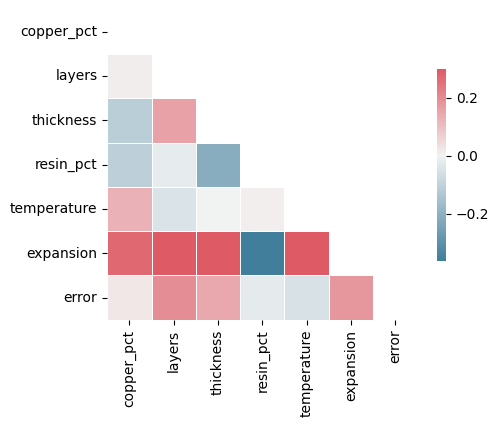

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(10, 10))
cmap = sns.diverging_palette(230, 10, as_cmap=True)

#draw heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .5})

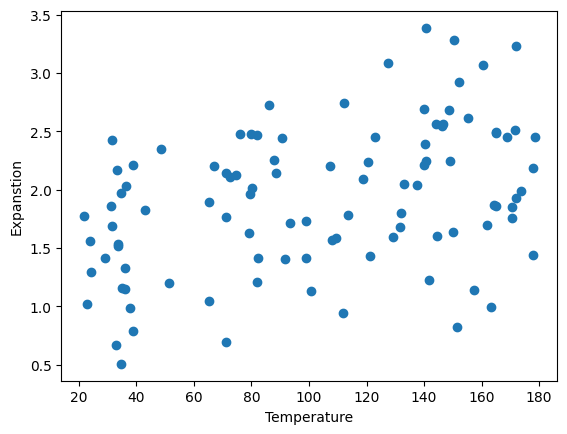

In [56]:
plt.scatter(
    df["temperature"],
    df["expansion"]
)

plt.xlabel("Temperature")
plt.ylabel("Expanstion")
plt.show()

In [57]:
X = df.drop(columns=["expansion"])
y = df["expansion"]

In [58]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [59]:
preds = model.predict(X)

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y, preds))
mae = mean_absolute_error(y, preds)

print(f"rmse: {rmse}\t\tmae: {mae}")

rmse: 0.19947683848164124		mae: 0.15874969103527958


In [61]:
pd.Series(
    model.coef_,
    index=X.columns
).sort_values(ascending=False)

thickness      0.378312
layers         0.078563
copper_pct     0.008416
temperature    0.004891
resin_pct     -0.016928
dtype: float64

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.01,
    random_state=42
)

gbr.fit(X,y)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [63]:
gbr_preds = gbr.predict(X)

gbr_rmse = np.sqrt(mean_squared_error(y, gbr_preds))
gbr_mae = mean_absolute_error(y, preds)

print(f"gbr_rmse: {gbr_rmse}\t\tgbr_mae: {gbr_mae}")

gbr_rmse: 0.3206063124659187		gbr_mae: 0.15874969103527958


In [64]:
pd.Series(
    gbr.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

thickness      0.354847
layers         0.337125
temperature    0.151364
copper_pct     0.084228
resin_pct      0.072436
dtype: float64

In [65]:
#cross validation

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

loo = LeaveOneOut()

scores = cross_val_score(
    Ridge(alpha=1.0),
    X,
    y,
    cv=loo,
    scoring="neg_mean_squared_error"
)

cv_ridge_rmse = np.sqrt(-scores.mean())

print(f"rmse: {cv_ridge_rmse}")

rmse: 0.21127057995584334


In [66]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

loo = LeaveOneOut()

scores = cross_val_score(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.01,
        random_state=42
    ),
    X,
    y,
    cv=loo,
    scoring="neg_mean_squared_error"
)

cv_gbr_rmse = np.sqrt(-scores.mean())

print(f"rmse: {cv_gbr_rmse}")

rmse: 0.4262988175152448


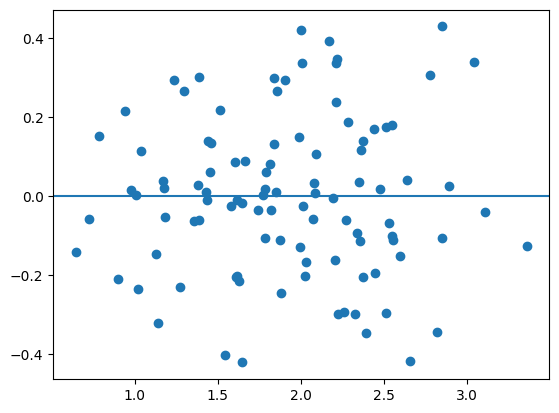

In [67]:
residuals = y - preds
plt.scatter(preds, residuals)
plt.axhline(0)

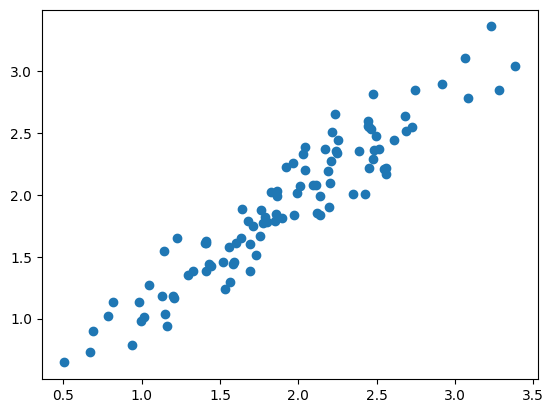

In [68]:
plt.scatter(y, preds)

(array([11.,  9., 10., 11.,  2., 10., 16.,  8.,  7., 16.]),
 array([0.51265396, 0.7546412 , 0.99662845, 1.23861569, 1.48060293,
        1.72259017, 1.96457742, 2.20656466, 2.4485519 , 2.69053914,
        2.93252639]),
 <BarContainer object of 10 artists>)

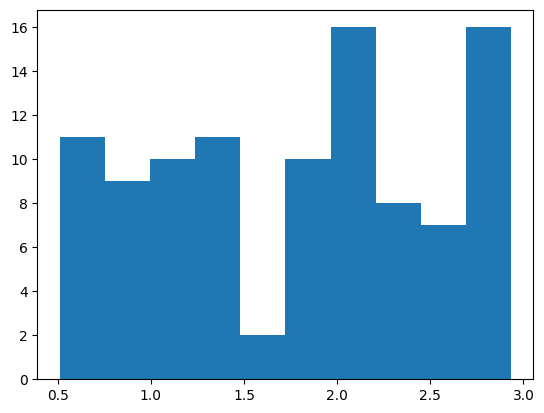

In [71]:
plt.hist(df["thickness"])

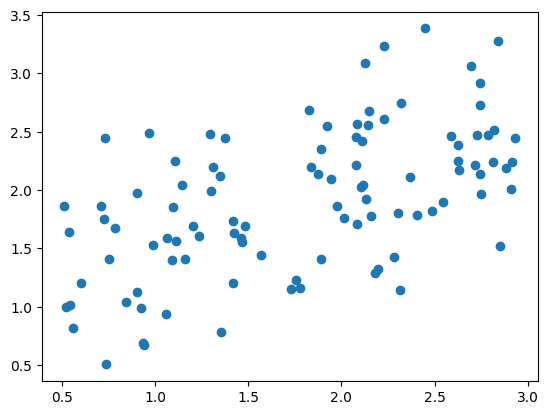

In [73]:
df["error"] = abs(y-preds)
plt.scatter(
    df["thickness"],
    df["expansion"]
)